# Stress 03 — The Causal Core: Confounding, Imperfect Controls, Collinearity & Selection

This is part 3 of a six-notebook series that deliberately tries to break the
framework on hard, realistic synthetic data — worlds where the ground truth is
known, so every estimate can be graded. The series thesis, established in
[stress_00](stress_00_the_rosy_picture.ipynb): **green diagnostics do not mean
correct attribution.** A model can converge cleanly, pass its posterior checks,
and still hand you a confidently wrong ROI.

Where [stress_01](stress_01_carryover_and_shape.ipynb) and
[stress_02](stress_02_time_structure.ipynb) attacked the *functional form*
(carryover, saturation, trend, seasonality), this notebook attacks the **causal
structure** — the assumptions no amount of curve flexibility can rescue:

| act | world | the failure | the pivot |
|---|---|---|---|
| 1 | `unobserved_confounding` | budgets chase latent demand; ROI absorbs demand's credit | control the demand proxy — and learn its limits |
| 2 | `multicollinearity` | channels bought together; the split is unidentified | honesty (wide intervals) + an experiment, **not** a prior |
| 3 | `dense_controls` *(new)* | 25 candidate controls on 156 weeks: confounder + decoys + noise | role-aware variable selection (never shrink a confounder) |
| 4 | back to act 1's world | nothing observational fixes the worst channel | **experiment calibration** — the real fix |

Each act follows the series template: *world → naive fit → truth gap →
diagnostics → pivot → measured improvement → takeaway*. The
[modeling walkthrough](mmm_walkthrough.ipynb) covers the full v1→v3 iteration
arc on a different (7-channel) world; here we isolate each causal failure in a
world built to exhibit exactly one.

> Fits use the series' fast config (numpyro, 300 draws × 2 chains) so the whole
> notebook bakes in minutes. Point estimates wobble a few percent versus
> production settings (≥1000 × 4); every qualitative claim below was checked
> against the slower stress-matrix runs in `tests/synth/`.

In [1]:
import sys, pathlib, warnings, logging
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
for _name in ("pymc", "numpyro", "jax", "arviz", "pytensor"):
    logging.getLogger(_name).setLevel(logging.ERROR)
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    # Hide sampler progress bars / chatter; our own prints stay visible.
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from tests.synth import dgp  # the synthetic violation worlds (ground truth known)

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")
PAL = {"TV": ACCENT, "Search": SKY, "Social": BERRY, "Display": LEAF}

In [2]:
import time
from dataclasses import replace
from mmm_framework.config import (
    CausalControlRole, ControlSelectionConfig, InferenceMethod, ModelConfig,
)
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

# Importing pymc installs its own log handler -> re-quiet and stop propagation.
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False

DRAWS, CHAINS = 300, 2
TIMINGS = {}

def fit_scenario(sc, *, selection="none", expected_nonzero=4, target_accept=0.9,
                 controls=None, experiments=None, label=""):
    # Build a (possibly control-subset) variant of the scenario and fit it.
    variant = sc
    if controls is not None:
        variant = replace(sc, controls=sc.controls[controls].copy())
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_chains=CHAINS, n_draws=DRAWS, n_tune=DRAWS,
        target_accept=target_accept, use_parametric_adstock=True, optim_seed=0,
        control_selection=ControlSelectionConfig(
            method=selection, expected_nonzero=expected_nonzero),
    )
    mmm = BayesianMMM(variant.panel(), cfg, TrendConfig(type=TrendType.LINEAR))
    if experiments:
        mmm.add_experiment_calibration(experiments)  # BEFORE fit
    t0 = time.perf_counter()
    with quiet():
        fit = mmm.fit(random_seed=0)
    TIMINGS[label] = round(time.perf_counter() - t0, 1)
    print(f"fit '{label}': {TIMINGS[label]}s   r-hat max = "
          f"{fit.diagnostics['rhat_max']:.3f}   divergences = "
          f"{fit.diagnostics['divergences']}")
    return variant, mmm, fit

def grade(variant, mmm):
    # Per-channel truth vs counterfactual estimate, with 90% HDI coverage.
    with quiet():
        contrib = mmm.compute_counterfactual_contributions(
            compute_uncertainty=True, hdi_prob=0.9, random_seed=0)
    rows = []
    for c in variant.channels:
        t = float(variant.true_contribution[c])
        e = float(contrib.total_contributions[c])
        lo = float(contrib.contribution_hdi_low[c])
        hi = float(contrib.contribution_hdi_high[c])
        rows.append({"channel": c, "true": round(t), "est": round(e),
                     "err": f"{(e - t) / t:+.0%}",
                     "err_frac": (e - t) / t,
                     "in 90% CI": "Y" if lo <= t <= hi else "N",
                     "rel_CI_width": round((hi - lo) / max(abs(e), 1e-9), 2)})
    df = pd.DataFrame(rows).set_index("channel")
    tot_t = float(variant.true_contribution.sum())
    tot_e = float(sum(contrib.total_contributions[c] for c in variant.channels))
    print(f"combined media contribution: true={tot_t:.0f}  est={tot_e:.0f}  "
          f"({(tot_e - tot_t) / tot_t:+.1%})")
    return df, contrib

def truth_vs_estimate(ax, variants, channels, title):
    # Grouped bars (one group per channel, one bar per model variant) with 90%
    # HDI whiskers, plus a black diamond at the true contribution.
    x = np.arange(len(channels))
    k = len(variants); w = 0.8 / k
    palette = [SKY, ACCENT, LEAF, AMBER, BERRY]
    for j, (label, (g, contrib)) in enumerate(variants.items()):
        est = np.array([float(contrib.total_contributions[c]) for c in channels])
        lo = np.array([float(contrib.contribution_hdi_low[c]) for c in channels])
        hi = np.array([float(contrib.contribution_hdi_high[c]) for c in channels])
        ax.bar(x + (j - (k - 1) / 2) * w, est, w * 0.92,
               yerr=[est - lo, hi - est], capsize=3, alpha=0.85,
               color=palette[j % len(palette)], label=label,
               error_kw={"lw": 1.1, "alpha": 0.8})
    truth = [float(next(iter(variants.values()))[0].loc[c, "true"]) for c in channels]
    ax.scatter(x, truth, marker="D", s=55, color=INK, zorder=5, label="TRUTH")
    ax.set_xticks(x); ax.set_xticklabels(channels)
    ax.set_ylabel("total incremental KPI"); ax.set_title(title)
    ax.legend(fontsize=8)

---
# Act 1 — Unobserved confounding: the #1 silent failure

**The world.** `unobserved_confounding` is the clean control world with exactly
one change: a latent demand signal (seasonal + growth + AR(1)) pushes **both**
the baseline *and* the budgets of the demand-chasing channels. Marketers do
this on purpose — bid harder when the category is hot. The model never sees the
demand series; it only sees spend and sales moving together.

Truth is the model's own estimand — the counterfactual zero-out of each
channel, evaluated on the noiseless structural mean — so any gap between truth
and estimate is *bias*, not an apples-to-oranges artifact.

demand-chasing channels (hidden from the model): ['Search', 'Social']


,"corr(spend, latent demand)"
TV,0.08
Search,0.35
Social,0.37
Display,0.03


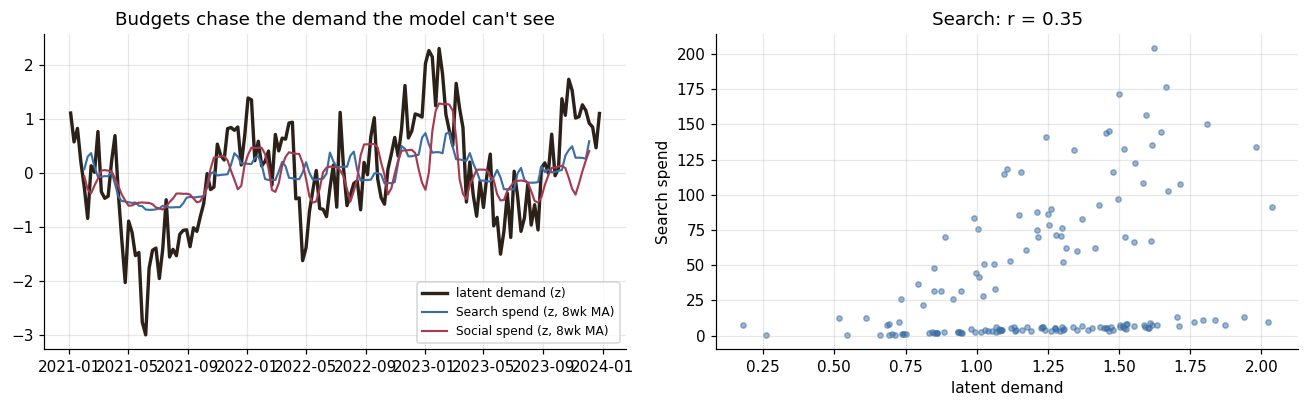

In [3]:
sc1 = dgp.build("unobserved_confounding")
demand = sc1.notes["latent_demand"]
chasers = sc1.notes["chasers"]
print("demand-chasing channels (hidden from the model):", chasers)

corr_d = pd.Series({c: np.corrcoef(sc1.spend[c], demand)[0, 1] for c in sc1.channels})
display(corr_d.round(2).to_frame("corr(spend, latent demand)"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
zd = (demand - demand.mean()) / demand.std()
axes[0].plot(sc1.weeks, zd, color=INK, lw=2.2, label="latent demand (z)")
for c in chasers:
    zs = (sc1.spend[c] - sc1.spend[c].mean()) / sc1.spend[c].std()
    axes[0].plot(sc1.weeks, zs.rolling(8, center=True).mean(), color=PAL[c],
                 lw=1.4, label=f"{c} spend (z, 8wk MA)")
axes[0].set_title("Budgets chase the demand the model can't see")
axes[0].legend(fontsize=8)
axes[1].scatter(demand, sc1.spend[chasers[0]], s=12, alpha=0.5, color=PAL[chasers[0]])
axes[1].set(xlabel="latent demand", ylabel=f"{chasers[0]} spend",
            title=f"{chasers[0]}: r = {corr_d[chasers[0]]:.2f}")
plt.tight_layout(); plt.show()

Note how *modest* those correlations look — nothing an EDA screen would scream
about. The bias below is large anyway, because the same demand signal also
drives the baseline hard: confounding strength is the **product** of both
paths, and the spend-side correlation alone understates it.

## The naive fit

In [4]:
v1a, m1a, f1a = fit_scenario(sc1, label="act1 naive")
g1a, c1a = grade(v1a, m1a)
g1a[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

combined media contribution: true=14885  est=15560  (+4.5%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,6309,5226,-17%,Y,0.63
Search,3654,5139,+41%,N,0.46
Social,2345,3234,+38%,N,0.45
Display,2577,1962,-24%,Y,1.09


Read the `err` column for the demand-chasers: both are **materially
over-credited, with the truth outside their 90% intervals**. (At this fast-fit
fidelity the worst chaser lands around +40% — the 2026-06-10 trend-prior
loosening lets the trend absorb part of the demand growth, roughly halving
what this same world used to log; the recorded stress matrix, run at higher
fidelity, has Search at **+153%**. Better, and still far outside any
acceptable error.) The channels that don't chase demand are fine — same
model, same data quality, same priors. The bias is surgical: it lands exactly
on the channels whose spend carries demand's fingerprint.

## And every diagnostic an analyst would check is green

This is what makes it the #1 *silent* failure. Run the standard dashboard:
convergence, posterior-predictive checks, and the unobserved-confounding
sensitivity analysis (Cinelli–Hazlett-style robustness values) that exists
precisely to catch this.

In [5]:
from mmm_framework.validation import ModelValidator, ValidationConfigBuilder

vcfg = (ValidationConfigBuilder().silent().without_residuals()
        .without_channel_diagnostics().with_unobserved_confounding()).build()
vcfg.run_model_comparison = False
vcfg.run_ppc = True
with quiet():
    vsum = ModelValidator(m1a).validate(vcfg)

rows = [
    ("r-hat (max)", f"{f1a.diagnostics['rhat_max']:.3f}",
     "PASS (fast-fit level; <1.01 at production draws)"),
    ("divergences", str(f1a.diagnostics["divergences"]),
     "PASS" if f1a.diagnostics["divergences"] == 0 else "CHECK"),
]
if vsum.ppc is not None:
    rows.append(("posterior predictive", "pass" if vsum.ppc.overall_pass else
                 f"flags: {vsum.ppc.problematic_checks}",
                 "same flags fire on the CLEAN control world (stress_00) -- "
                 "an analyst calibrated to this suite discounts them"))
if vsum.unobserved_confounding is not None:
    rvs = {c.channel: round(float(c.robustness_value), 2)
           for c in vsum.unobserved_confounding.channels}
    rows.append(("robustness values (RV)", str(rvs),
                 f"fragile channels flagged: "
                 f"{vsum.unobserved_confounding.fragile_channels or 'NONE'}"))
dash = pd.DataFrame(rows, columns=["check", "result", "reading"]).set_index("check")
pd.set_option("display.max_colwidth", 110)
display(dash)

2026-07-09 00:29:57.978 | DEBUG    | mmm_framework.validation.posterior_predictive:_get_observed_data:366 - PPC: Using y_raw, shape=(156,), range=[250.02, 603.04]


2026-07-09 00:29:57.978 | DEBUG    | mmm_framework.validation.posterior_predictive:_generate_replicated_data:414 - PPC replicated: y_mean=423.89, y_std=79.22


2026-07-09 00:29:57.979 | DEBUG    | mmm_framework.validation.posterior_predictive:_generate_replicated_data:419 - PPC replicated: Trying predict() method


Output()

2026-07-09 00:29:58.167 | DEBUG    | mmm_framework.validation.posterior_predictive:_generate_replicated_data:427 - PPC replicated: predict() returned shape=(600, 156), range=[179.20, 691.38]


,result,reading
check,,
r-hat (max),1.015,PASS (fast-fit level; <1.01 at production draws)
divergences,0,PASS
posterior predictive,flags: ['Autocorrelation'],same flags fire on the CLEAN control world (stress_00) -- an analyst calibrated to this suite discounts them
robustness values (RV),"{'TV': 0.18, 'Search': 0.23, 'Social': 0.2, 'Display': 0.11}",fragile channels flagged: NONE


In [6]:
# VERIFY (seeded, directional): the silent-failure shape of act 1.
# (Magnitudes are config-dependent: the 2026-06-10 trend-prior fix halved the
# bias at this fidelity from ~+110% to ~+40%; the harness recording is +153%.)
worst = g1a["err_frac"].abs().idxmax()
assert worst in chasers, f"worst-biased channel {worst} should be a demand-chaser"
assert g1a.loc[worst, "err_frac"] > 0.30, "worst chaser materially overstated"
assert f1a.diagnostics["divergences"] == 0, "sampler itself is healthy"
assert (g1a["in 90% CI"] == "N").sum() >= 1, "truth should escape at least one CI"
assert not vsum.unobserved_confounding.fragile_channels, \
    "the RV screen stays quiet on exactly the failure it targets"
print(f"confirmed: {worst} is {g1a.loc[worst, 'err']} overstated; sampler clean; "
      "RV screen silent.")

confirmed: Search is +41% overstated; sampler clean; RV screen silent.


> **Takeaway 1a.** The sampler is healthy, the fit is good, and the sensitivity
> screen built for unobserved confounding does not fire — the bias is carried
> by a *plausible* posterior, not a strained one. Exogeneity is an assumption
> **about the world**, and no within-model diagnostic can audit the world.

## The pivot: control the confounder — through the proxy you actually have

In real life you never observe demand itself; you observe a **proxy** (a
category index, search-trends panel, distribution data). The
`confounding_controlled` twin of this world adds exactly that: the same latent
demand, observed as `CategoryDemand = 100·demand + noise`, included as a
control and **marked `CONFOUNDER`** so it gets the wide, un-shrunk prior
(`sigma=2.0`) instead of the regularizing precision prior (`sigma=0.5`).
Shrinking a confounder would re-open the very back-door you are closing.

In [7]:
sc1c = dgp.build("confounding_controlled")
print("controls:", list(sc1c.controls.columns), "  roles:", sc1c.control_roles)
v1b, m1b, f1b = fit_scenario(sc1c, label="act1 proxy-controlled")
g1b, c1b = grade(v1b, m1b)
g1b[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

controls: ['Price', 'CategoryDemand']   roles: {'CategoryDemand': <CausalControlRole.CONFOUNDER: 'confounder'>}


  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

fit 'act1 proxy-controlled': 6.1s   r-hat max = 1.018   divergences = 0


...

Output()

Output()

Output()

combined media contribution: true=14885  est=15412  (+3.5%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,6309,5857,-7%,Y,0.54
Search,3654,4563,+25%,N,0.42
Social,2345,2786,+19%,Y,0.46
Display,2577,2206,-14%,Y,0.71


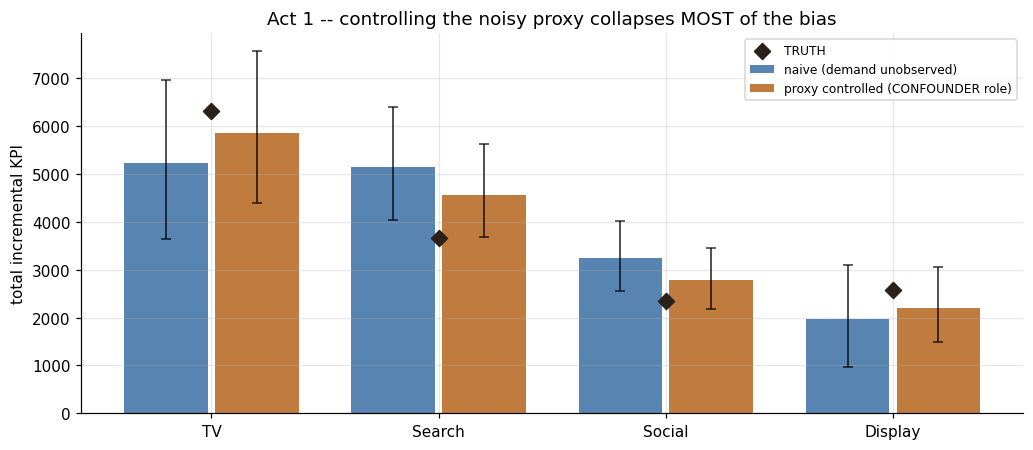

,naive err,controlled err,covered (naive),covered (controlled)
channel,,,,
TV,-17%,-7%,Y,Y
Search,+41%,+25%,N,N
Social,+38%,+19%,N,Y
Display,-24%,-14%,Y,Y


In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
truth_vs_estimate(ax, {"naive (demand unobserved)": (g1a, c1a),
                       "proxy controlled (CONFOUNDER role)": (g1b, c1b)},
                  sc1.channels,
                  "Act 1 -- controlling the noisy proxy collapses MOST of the bias")
plt.tight_layout(); plt.show()

cmp1 = pd.DataFrame({"naive err": g1a["err"], "controlled err": g1b["err"],
                     "covered (naive)": g1a["in 90% CI"],
                     "covered (controlled)": g1b["in 90% CI"]})
display(cmp1)

In [9]:
# VERIFY: the proxy helps a lot -- and not enough.
assert abs(g1b.loc[worst, "err_frac"]) < abs(g1a.loc[worst, "err_frac"]) * 0.75, \
    "controlling the proxy should remove a large share of the worst bias"
assert abs(g1b.loc[worst, "err_frac"]) > 0.10, \
    "residual bias should remain (the proxy is noisy)"
print(f"{worst}: {g1a.loc[worst, 'err']} naive -> {g1b.loc[worst, 'err']} "
      "controlled. A large share of the bias gone; a real residual remains.")

Search: +41% naive -> +25% controlled. A large share of the bias gone; a real residual remains.


> **Takeaway 1b.** "We controlled for it" is **not a guarantee.** The proxy
> measures demand with error, and measurement error in a confounder only
> *partially* closes the back-door — the worst channel keeps a double-digit
> overstatement with the truth still outside its interval. Two spec decisions
> did the work that *was* done: including the proxy at all, and assigning it
> the `CONFOUNDER` role so it isn't shrunk. Proxy **quality** sets the floor on
> the residual bias, and nothing in the data tells you where that floor is.
> Hold that thought for act 4.

---
# Act 2 — Collinearity: the model can't split what the buy didn't split

**The world.** `multicollinearity` keeps the same deep flighting pulses as the
clean world — total media is just as identifiable — but drives every channel
from **one shared burst calendar** (channels bought together, one trafficking
plan). Each channel keeps its own true effect; only the *separability* is gone.

The five-second EDA catch first:

mean pairwise spend correlation: 0.996


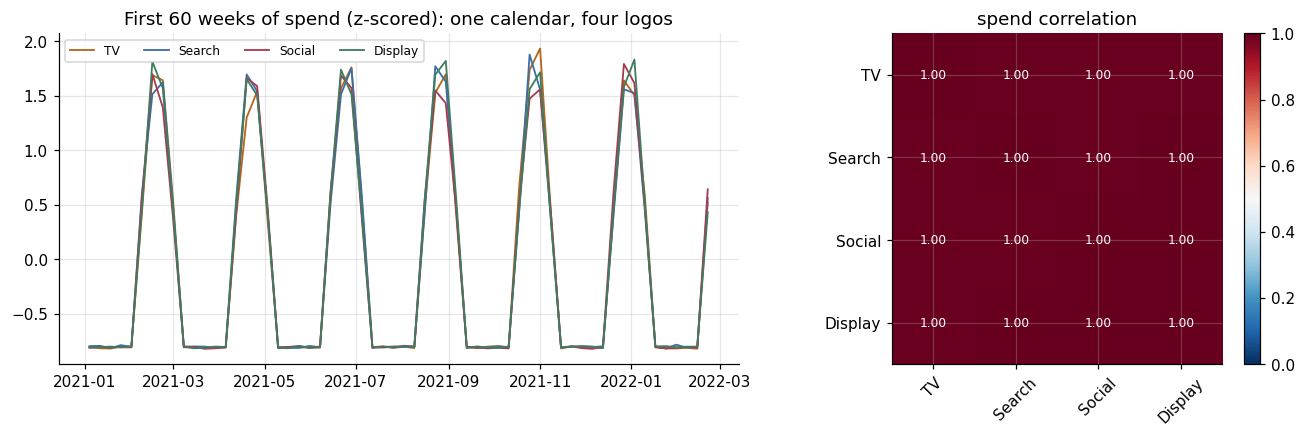

In [10]:
sc2 = dgp.build("multicollinearity")
corr2 = sc2.spend.corr()
print(f"mean pairwise spend correlation: "
      f"{sc2.notes['mean_pairwise_corr']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0),
                         gridspec_kw={"width_ratios": [1.6, 1]})
zs = (sc2.spend - sc2.spend.mean()) / sc2.spend.std()
for c in sc2.channels:
    axes[0].plot(sc2.weeks[:60], zs[c][:60], color=PAL[c], lw=1.2, label=c)
axes[0].set_title("First 60 weeks of spend (z-scored): one calendar, four logos")
axes[0].legend(fontsize=8, ncol=4)
im = axes[1].imshow(corr2, vmin=0, vmax=1, cmap="RdBu_r")
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(corr2.columns, rotation=45)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(corr2.columns)
for (i, j), v in np.ndenumerate(corr2.values):
    axes[1].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white")
axes[1].set_title("spend correlation"); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

In [11]:
v2, m2, f2 = fit_scenario(sc2, label="act2 collinear")
g2, c2 = grade(v2, m2)
g2[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

fit 'act2 collinear': 7.5s   r-hat max = 1.020   divergences = 0


Output()

Output()

Output()

Output()

combined media contribution: true=23273  est=23599  (+1.4%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,8800,8950,+2%,Y,1.71
Search,5678,4551,-20%,Y,2.38
Social,5263,6581,+25%,Y,2.11
Display,3531,3516,-0%,Y,2.85


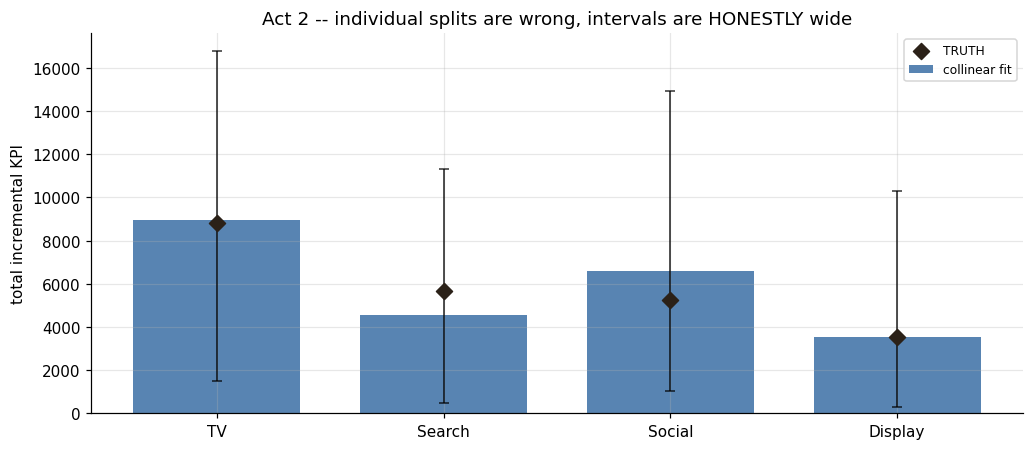

Per-channel point errors vs combined-media error:
channel
TV          +2%
Search     -20%
Social     +25%
Display     -0%

combined media: +1.4% (the data DOES identify the total)
rel_CI_width (interval width / estimate):
channel
TV         1.71
Search     2.38
Social     2.11
Display    2.85


In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
truth_vs_estimate(ax, {"collinear fit": (g2, c2)}, sc2.channels,
                  "Act 2 -- individual splits are wrong, intervals are HONESTLY wide")
plt.tight_layout(); plt.show()

print("Per-channel point errors vs combined-media error:")
print(g2["err"].to_string())
tot_t = float(v2.true_contribution.sum())
tot_e = float(sum(c2.total_contributions[c] for c in v2.channels))
print(f"\ncombined media: {(tot_e - tot_t) / tot_t:+.1%} "
      "(the data DOES identify the total)")
print("rel_CI_width (interval width / estimate):")
print(g2["rel_CI_width"].to_string())

In [13]:
# VERIFY: wrong splits, right total, honest intervals.
assert sc2.notes["mean_pairwise_corr"] > 0.85
assert g2["err_frac"].abs().max() > 0.12, \
    "splits should drift materially (harness recording at PyMC fidelity: +60-80%)"
assert abs(tot_e - tot_t) / tot_t < 0.25, "combined media should be ~right"
assert (g2["rel_CI_width"] > 1.0).all(), \
    "every channel's 90% interval should be wider than its own estimate"
print("confirmed: splits wrong, total right, every interval wider than its estimate.")

confirmed: splits wrong, total right, every interval wider than its estimate.


## The posterior seesaw: correlation between the contribution estimates

Wide per-channel intervals are only half of what the posterior is telling you.
The other half lives in the **joint** distribution: sum each channel's
contribution over time *per posterior draw* and correlate the totals across
channels. In a well-identified fit those correlations sit near zero (measured
on the clean control in [stress_00](stress_00_the_rosy_picture.ipynb) §3.1 —
distinct flighting calendars, separable channels, |corr| ≈ 0). Here every
channel was bought on **one calendar**, and the posterior says so in its own
language: draws where one channel takes more credit are draws where its
shelf-mates take **less** — the split is a seesaw, conserved in total and
arbitrary in allocation.

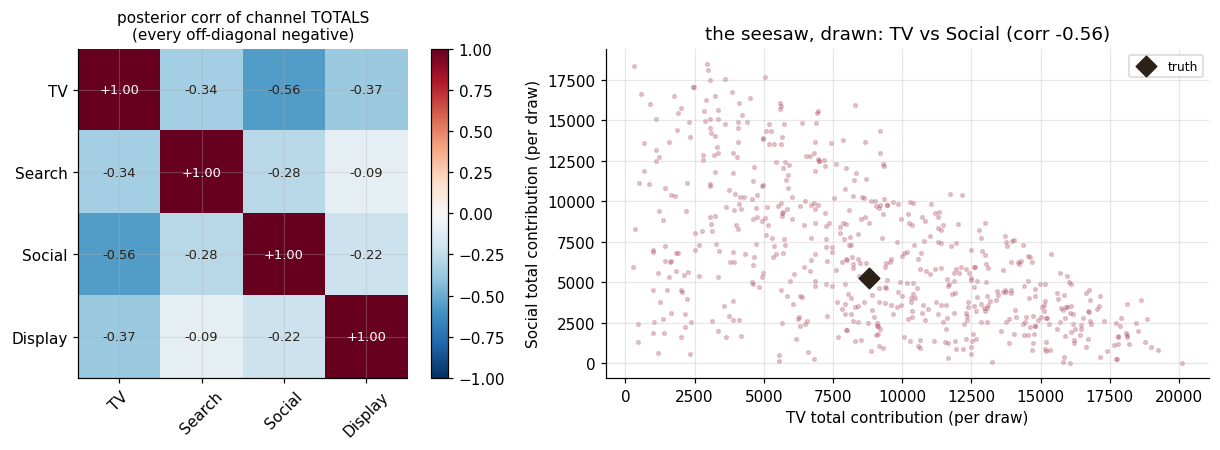

pairwise correlations: [-0.34 -0.56 -0.37 -0.28 -0.09 -0.22]
confirmed: all pairwise correlations negative -- the posterior conserves the total and
shuffles the split. THIS is the plot that says 'buy an experiment, not a tighter prior'.


In [14]:
post2 = f2.trace.posterior["channel_contributions"].values
draws2 = post2.reshape(-1, post2.shape[2], post2.shape[3]) * m2.y_std
totals2 = draws2.sum(axis=1)                       # (n_draws, n_channels)
corr2p = pd.DataFrame(np.corrcoef(totals2.T), index=sc2.channels, columns=sc2.channels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2),
                         gridspec_kw={"width_ratios": [1, 1.25]})
im = axes[0].imshow(corr2p, vmin=-1, vmax=1, cmap="RdBu_r")
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(sc2.channels, rotation=45)
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(sc2.channels)
for (i, j), v in np.ndenumerate(corr2p.values):
    axes[0].text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8.5,
                 color="white" if abs(v) > 0.6 else INK)
axes[0].set_title("posterior corr of channel TOTALS\n(every off-diagonal negative)",
                  fontsize=10)
fig.colorbar(im, ax=axes[0], fraction=0.046)

off_pairs = [(a, b) for ai, a in enumerate(sc2.channels)
             for b in sc2.channels[ai + 1:]]
worst_pair = min(off_pairs, key=lambda p: corr2p.loc[p[0], p[1]])
a, b = worst_pair
ai, bi = sc2.channels.index(a), sc2.channels.index(b)
axes[1].scatter(totals2[:, ai], totals2[:, bi], s=6, alpha=0.25, color=BERRY)
axes[1].scatter([float(v2.true_contribution[a])], [float(v2.true_contribution[b])],
                marker="D", s=90, color=INK, zorder=5, label="truth")
axes[1].set(xlabel=f"{a} total contribution (per draw)",
            ylabel=f"{b} total contribution (per draw)",
            title=f"the seesaw, drawn: {a} vs {b} "
                  f"(corr {corr2p.loc[a, b]:+.2f})")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

off_vals = corr2p.values[np.triu_indices(4, 1)]
print("pairwise correlations:", np.round(off_vals, 2))

# VERIFY: the collinear posterior's signature — credit is traded, not pinned.
assert off_vals.max() < 0.05, "every pair should trade off (no positive corr)"
assert off_vals.min() < -0.35, "the worst pair should be strongly negative"
assert (off_vals < -0.20).sum() >= 3, "most pairs materially negative"
print("confirmed: all pairwise correlations negative -- the posterior conserves "
      "the total and\nshuffles the split. THIS is the plot that says 'buy an "
      "experiment, not a tighter prior'.")

> **Reading it.** The heatmap is the model's own confession, available in every
> real engagement (no ground truth required): strongly negative contribution
> correlations mean the likelihood pins the **sum** while the **allocation**
> floats. Two practical uses: (1) *grouping* — channels whose totals correlate
> below ≈ −0.3 should be reported as a group until an experiment splits them;
> (2) *experiment design* — the scatter shows one lift test on either member
> collapses the seesaw, because conditioning on one coordinate pins the other.
> That is exactly what act 4 does.

> **Takeaway 2.** This failure is **loud, if you listen to the right channel of
> the posterior.** The point estimates shuffle real credit between channels —
> but every per-channel interval is *wider than the estimate itself*, while the
> combined-media total lands close to truth. That interval pattern is the model
> saying, in its own language, *"I can see what media does; I cannot see which
> channel does it."* The wrong move is tightening priors until the intervals
> look presentable — that manufactures a split the data does not contain, and
> whoever sets the prior sets the ROI. The right moves are honesty (report the
> group, not the members) and **an experiment on one channel of the group**,
> which pins one member and lets subtraction identify the rest. The same logic
> resolves Radio/Print in the [walkthrough](mmm_walkthrough.ipynb); act 4 shows
> the calibration machinery itself.

---
# Act 3 — Dense controls and variable selection (a brand-new world)

Acts 1–2 had one or two controls. Real briefs arrive with a *spreadsheet*:
macro indices, weather, pricing, promos, category trackers, competitor pulls —
some causal, most not, several suspiciously co-moving with your own media.
Including everything costs precision (25 coefficients on 156 weeks); dropping
the wrong one re-opens act 1. **Which controls you keep is a causal decision,
but how you regularize the keepers is a statistical one** — and this act tests
the framework's machinery for splitting that difference: role-aware variable
selection, where *selection priors apply only to nuisance candidates and
confounders are exempt by construction*.

**The world** (`dense_controls`, first exercised here): 25 candidate controls,
each group a different trap —

* `demand_proxy` — a genuine **confounder**: latent demand drives sales *and*
  the TV/Search budgets chase it (act 1's mechanism, embedded in the pile);
* `price`, `weather` — genuine **precision controls** (real, modest effects);
* `noise_1..18` — pure-noise random walks, true effect zero, but random walks
  *will* spuriously correlate with a trending KPI on 156 weeks;
* `decoy_tv/search/social/display` — **media-tracking decoys**: noisy copies
  of each channel's spend (corr ≈ 0.9) with **no causal effect** — the designed
  bait for any selector that picks controls by correlation.

In [15]:
sc3 = dgp.build("dense_controls")
groups = {"confounder": ["demand_proxy"],
          "precision": ["price", "weather"],
          "noise": sc3.notes["noise_controls"],
          "decoy": sc3.notes["decoy_controls"]}
role_of = {c: g for g, cs in groups.items() for c in cs}

rows = []
for col in sc3.controls.columns:
    cy = abs(np.corrcoef(sc3.controls[col], sc3.y)[0, 1])
    cs = max(abs(np.corrcoef(sc3.controls[col], sc3.spend[ch])[0, 1])
             for ch in sc3.channels)
    rows.append((col, role_of[col], round(cy, 2), round(cs, 2)))
census = pd.DataFrame(rows, columns=["control", "true role", "|corr y|",
                                     "max |corr spend|"])
print(f"{len(census)} candidate controls on {len(sc3.y)} weeks")
display(census.sort_values("|corr y|", ascending=False).head(10).reset_index(drop=True))
print("(decoys correlate ~0.9 with their channel's spend AND, through media, "
      "with y -- correlation screens cannot separate them from a confounder)")
print("\nconfounded spend:", {c: round(np.corrcoef(sc3.spend[c],
      sc3.notes['latent_demand'])[0, 1], 2) for c in ["TV", "Search"]})

25 candidate controls on 156 weeks


,control,true role,|corr y|,max |corr spend|
0,demand_proxy,confounder,0.79,0.43
1,decoy_search,decoy,0.54,0.91
2,weather,precision,0.48,0.10
3,noise_3,noise,0.42,0.20
4,decoy_tv,decoy,0.40,0.92
5,price,precision,0.36,0.25
6,noise_4,noise,0.35,0.18
7,noise_13,noise,0.31,0.11
8,noise_2,noise,0.26,0.10
9,noise_14,noise,0.26,0.08


(decoys correlate ~0.9 with their channel's spend AND, through media, with y -- correlation screens cannot separate them from a confounder)

confounded spend: {'TV': np.float64(0.42), 'Search': np.float64(0.43)}


**The contest.** Four fits, identical except for how the controls enter:

| variant | controls | coefficient prior on controls |
|---|---|---|
| (a) kitchen sink | all 25 | role widths only (confounder wide, rest `sigma=0.5`) — no selection |
| (b) horseshoe | all 25 | regularized horseshoe on the 24 *non-confounder* controls, `expected_nonzero=4`; confounder exempt |
| (c) **oracle** | the 3 truly-causal only | role widths — the benchmark you can't run in real life |
| (d) spike-and-slab | all 25 | as (b) with a spike-slab selector (sensitivity row) |

The roles come from `sc.control_roles` → `ControlVariableConfig.causal_role` —
they are **asserted spec**, not learned. The selection machinery's contract
(`model/base.py:_build_control_betas`): confounder-role controls keep the wide
un-shrunk Normal *no matter what*, because a shrunk confounder is a half-open
back-door (act 1b showed what even a *noisy* one costs).

In [16]:
v3a, m3a, f3a = fit_scenario(sc3, label="act3 (a) all-25 no selection")
g3a, c3a = grade(v3a, m3a)
g3a[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

fit 'act3 (a) all-25 no selection': 10.1s   r-hat max = 1.032   divergences = 0


Output()

Output()

Output()

Output()

combined media contribution: true=15220  est=14666  (-3.6%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,4932,5712,+16%,Y,0.63
Search,3308,3133,-5%,Y,0.86
Social,4369,4492,+3%,Y,0.72
Display,2611,1329,-49%,Y,1.95


In [17]:
v3b, m3b, f3b = fit_scenario(sc3, selection="horseshoe", expected_nonzero=4,
                             target_accept=0.95, label="act3 (b) horseshoe")
g3b, c3b = grade(v3b, m3b)
g3b[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

Output()

Output()

Output()

combined media contribution: true=15220  est=14673  (-3.6%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,4932,5036,+2%,Y,0.65
Search,3308,3468,+5%,Y,0.55
Social,4369,4625,+6%,Y,0.46
Display,2611,1544,-41%,N,1.11


In [18]:
v3c, m3c, f3c = fit_scenario(sc3, controls=["demand_proxy", "price", "weather"],
                             label="act3 (c) oracle 3 controls")
g3c, c3c = grade(v3c, m3c)
g3c[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

fit 'act3 (c) oracle 3 controls': 6.4s   r-hat max = 1.014   divergences = 0


Output()

Output()

Output()

Output()

combined media contribution: true=15220  est=14626  (-3.9%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,4932,4987,+1%,Y,0.64
Search,3308,3498,+6%,Y,0.53
Social,4369,4499,+3%,Y,0.42
Display,2611,1641,-37%,N,1.03


In [19]:
v3d, m3d, f3d = fit_scenario(sc3, selection="spike_slab", target_accept=0.95,
                             label="act3 (d) spike-slab")
g3d, c3d = grade(v3d, m3d)
g3d[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

fit 'act3 (d) spike-slab': 13.0s   r-hat max = 1.025   divergences = 0


...

Output()

Output()

Output()

combined media contribution: true=15220  est=15048  (-1.1%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,4932,5270,+7%,Y,0.63
Search,3308,3485,+5%,Y,0.58
Social,4369,4674,+7%,Y,0.48
Display,2611,1619,-38%,Y,1.19


## Who survived selection? Reading `beta_controls`

The contract preserves a single `beta_controls` node whichever prior is active,
so the same inspection works for all variants: posterior means by control,
grouped by true role, and a "survivor" test (does the 90% HDI exclude zero?).

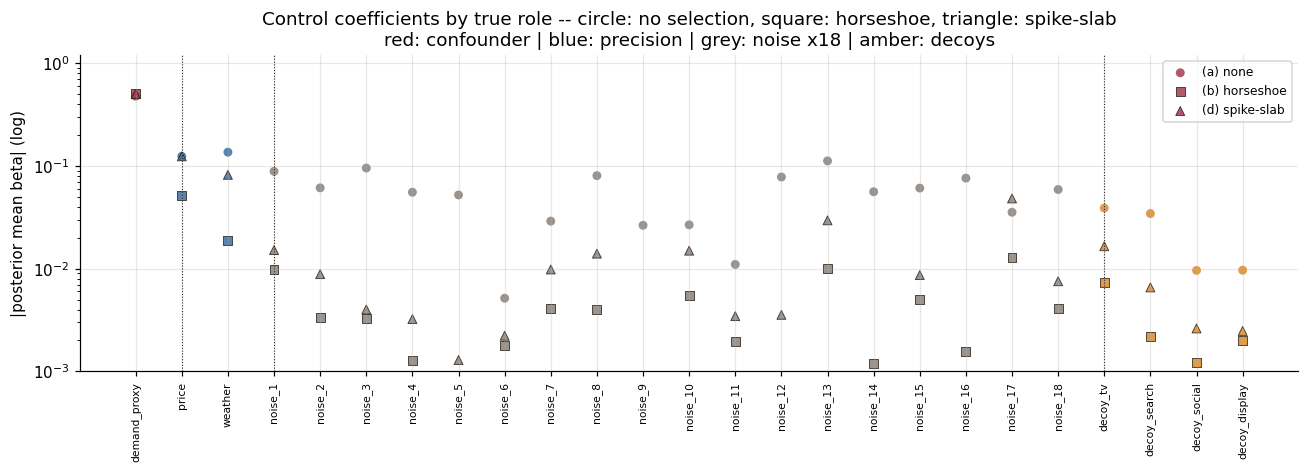

In [20]:
import arviz as az

def control_betas(fit, mmm):
    return pd.Series(fit.trace.posterior["beta_controls"]
                     .mean(dim=["chain", "draw"]).values, index=mmm.control_names)

cm = {"(a) none": control_betas(f3a, m3a),
      "(b) horseshoe": control_betas(f3b, m3b),
      "(d) spike-slab": control_betas(f3d, m3d)}

order = groups["confounder"] + groups["precision"] + groups["noise"] + groups["decoy"]
gcolor = {"confounder": BERRY, "precision": SKY, "noise": MUTED, "decoy": AMBER}
fig, ax = plt.subplots(figsize=(12, 4.4))
x = np.arange(len(order))
for (label, s), mk in zip(cm.items(), ["o", "s", "^"]):
    ax.scatter(x, s[order].abs(), marker=mk, s=34, alpha=0.85, label=label,
               color=[gcolor[role_of[c]] for c in order],
               edgecolors=INK if mk != "o" else "none", linewidths=0.6)
ax.set_yscale("log"); ax.set_ylim(1e-3, 1.2)
for b in [0.5, 2.5, 20.5]:
    ax.axvline(b + 0.5, color=INK, lw=0.7, ls=":")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel("|posterior mean beta| (log)")
ax.set_title("Control coefficients by true role -- circle: no selection, "
             "square: horseshoe, triangle: spike-slab\n"
             "red: confounder | blue: precision | grey: noise x18 | amber: decoys")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [21]:
def group_mean_abs(s):
    return pd.Series({g: s[cs].abs().mean() for g, cs in groups.items()})

shrink = pd.DataFrame({k: group_mean_abs(s) for k, s in cm.items()}).round(3)
display(shrink)

from mmm_framework.utils import arviz_compat
# arviz 1.x: az.hdi on a bare DataArray is not var-name indexable; use the trace-level shim
hdi_b = arviz_compat.hdi_dataset(f3b.trace, 0.9, var_names=["beta_controls"])["beta_controls"].values
survivors = [n for i, n in enumerate(m3b.control_names)
             if not (float(hdi_b[i, 0]) <= 0 <= float(hdi_b[i, 1]))]
print("horseshoe survivors (90% HDI excludes 0):",
      [(n, role_of[n]) for n in survivors])
print("\ndecoy fate under each prior (posterior mean beta):")
display(pd.DataFrame({k: s[groups["decoy"]].round(3) for k, s in cm.items()}))

,(a) none,(b) horseshoe,(d) spike-slab
confounder,0.477,0.510,0.498
precision,0.130,0.035,0.103
noise,0.056,0.004,0.010
decoy,0.023,0.003,0.007


horseshoe survivors (90% HDI excludes 0): [('demand_proxy', 'confounder')]

decoy fate under each prior (posterior mean beta):


,(a) none,(b) horseshoe,(d) spike-slab
decoy_tv,-0.039,-0.007,-0.017
decoy_search,0.034,0.002,0.007
decoy_social,-0.010,-0.001,-0.003
decoy_display,0.010,-0.002,-0.002


## What the dense set actually cost — and what selection actually bought

Score all four variants on media recovery:

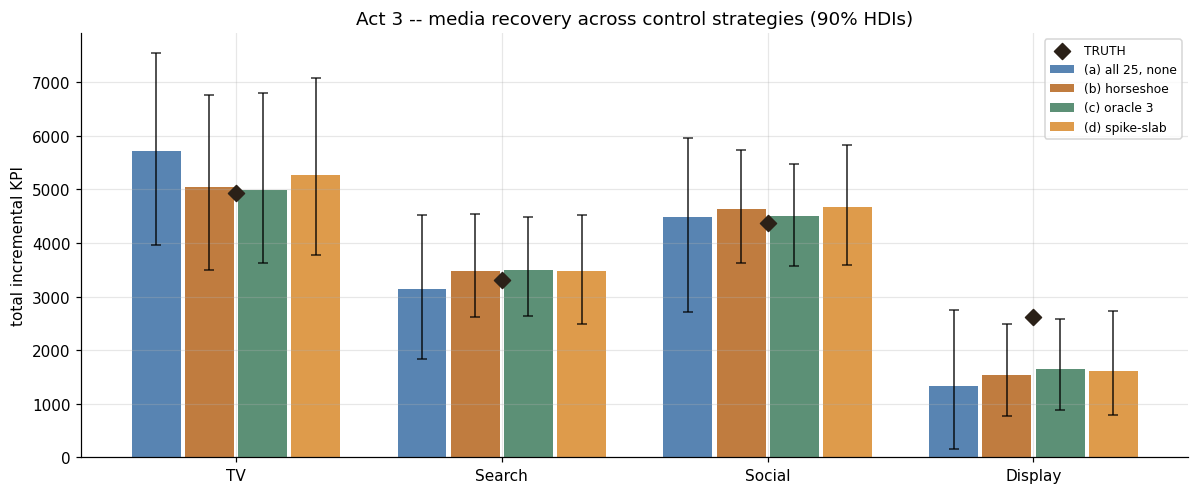

,mean |err|,max |err|,covered,mean rel CI width
"(a) all 25, none",18%,49%,4/4,1.04
(b) horseshoe,13%,41%,3/4,0.69
(c) oracle 3,12%,37%,3/4,0.66
(d) spike-slab,14%,38%,4/4,0.72


In [22]:
fig, ax = plt.subplots(figsize=(11, 4.6))
variants3 = {"(a) all 25, none": (g3a, c3a), "(b) horseshoe": (g3b, c3b),
             "(c) oracle 3": (g3c, c3c), "(d) spike-slab": (g3d, c3d)}
truth_vs_estimate(ax, variants3, sc3.channels,
                  "Act 3 -- media recovery across control strategies (90% HDIs)")
plt.tight_layout(); plt.show()

score = pd.DataFrame({
    k: {"mean |err|": f"{g['err_frac'].abs().mean():.0%}",
        "max |err|": f"{g['err_frac'].abs().max():.0%}",
        "covered": f"{(g['in 90% CI'] == 'Y').sum()}/4",
        "mean rel CI width": round(g["rel_CI_width"].mean(), 2)}
    for k, (g, _) in variants3.items()}).T
display(score)

In [23]:
# VERIFY the selection mechanics (seeded, with margin):
b_none, b_hs = cm["(a) none"], cm["(b) horseshoe"]
assert b_hs[groups["noise"]].abs().mean() < 0.5 * b_none[groups["noise"]].abs().mean(), \
    "horseshoe should shrink the noise pile at least 2x harder than the Normal"
assert b_hs[groups["decoy"]].abs().mean() < 0.5 * b_none[groups["decoy"]].abs().mean(), \
    "decoys should be shrunk harder too"
assert abs(b_hs["demand_proxy"]) > 0.3, "the confounder must KEEP its coefficient"
assert abs(b_hs["demand_proxy"]) >= abs(b_none["demand_proxy"]) - 0.05, \
    "selection must not shrink the exempt confounder"
assert "demand_proxy" in survivors, "the confounder survives by construction"
mean_err = {k: g["err_frac"].abs().mean() for k, (g, _) in variants3.items()}
assert mean_err["(b) horseshoe"] <= mean_err["(a) all 25, none"] + 0.05, \
    "selection should not damage media recovery"
print("mechanics confirmed: noise/decoys shrunk hard, confounder untouched, "
      f"media recovery: { {k: f'{v:.0%}' for k, v in mean_err.items()} }")

mechanics confirmed: noise/decoys shrunk hard, confounder untouched, media recovery: {'(a) all 25, none': '18%', '(b) horseshoe': '13%', '(c) oracle 3': '12%', '(d) spike-slab': '14%'}


**Honest findings — including the one we didn't design for.**

1. **The decoys did not steal media's credit — under *any* prior.** They were
   built as the trap (corr ≈ 0.9 with spend, zero causal effect), yet even the
   no-selection fit hands them near-zero coefficients. Why: the decoys track
   *raw spend levels*, but the media regressor the likelihood actually sees is
   the **adstocked, saturated transform** of spend. The nonlinear media
   pipeline is itself a mild identification device — a linear shadow of a
   channel is not collinear with the channel's transformed effect. That is a
   genuine robustness property of the model family, *and* a warning about its
   boundary: a decoy that tracked the channel's transformed response (a
   competitor mirroring your flighting *and* carryover) would not be separated
   this way.
2. **The real cost of the kitchen sink is precision, not theft.** Compare
   variant (a) to the oracle in the score table: the weakest channel's interval
   roughly doubles, and per-channel errors drift. Twenty-two junk coefficients
   don't *bias* a role-correct model much — they *blur* it.
3. **Selection bought the oracle's accuracy without the oracle's knowledge.**
   The horseshoe (and spike-slab, nearly identically) shrinks the noise pile
   and the decoys several-fold, keeps the confounder at full strength —
   `demand_proxy` is the lone survivor of the HDI test — and the media recovery
   matches or beats the oracle's, while restoring most of the lost interval
   width. `expected_nonzero≈4` encodes the *prior belief* "a few of these are
   real"; it is a dial, not a discovery.
4. **The known cost, reproduced:** the horseshoe **over-shrinks the genuine
   precision controls** (compare `price`/`weather` across the (a) and (b)
   columns of the shrinkage table — the no-selection estimates sit near their
   true standardized values, the horseshoe's well below). In this low-SNR
   regime selection buys junk-suppression at the price of attenuating real-but-
   weak nuisance effects. That trade is usually worth it for *media* accuracy —
   the controls are not the deliverable — but it is why selection is
   off-by-default and **why a confounder must never be left in the selectable
   pool**: what it does to `weather` it would do to your back-door.
5. One channel stays materially under-credited in **every** variant, oracle
   included — its bias is a property of this world's low SNR for that channel,
   not of the control strategy. Selection fixes the control problem; it does
   not manufacture identification that isn't there.

> **Takeaway 3.** Causal roles are **spec**; selection is **statistics**; keep
> them in that order. Classify first (act 1's lesson: the confounder gets the
> wide prior, mediators get excluded — the model refuses them outright), then
> let a selection prior tidy the nuisance pile you couldn't classify. A
> selector that can shrink a confounder, or a workflow that picks controls by
> correlation with y, is act 1 with extra steps.

---
# Act 4 — The real fix: experiment calibration

Act 1 ended with an uncomfortable residue: even with the proxy controlled, the
worst channel kept a double-digit bias, and *nothing in the data* can locate
the floor that proxy noise sets. Act 2 ended with an honest shrug. Both point
the same way: **the information that identifies a confounded or collinear
channel is not in the observational data — you have to buy it.**

A geo lift test measures a channel's incremental effect by randomization,
immune to demand-chasing by design. The framework folds it into the model as an
**in-graph likelihood term** (`add_experiment_calibration`, called before
`fit`): the measured value becomes a data point whose model expectation is the
channel's own estimand — here ROAS — expressed through the same `beta`,
saturation, and adstock parameters the time series informs. The experiment and
the time series then *negotiate* in one posterior. (Mechanics and the
prior-route alternative: [math_05_calibration](math_05_calibration.ipynb).)

We simulate the test the way a real one works: it measures the **truth**
(`sc.true_roas`) with sampling error — a 10% SE, a well-powered test.

In [24]:
from mmm_framework.calibration import ExperimentEstimand, ExperimentMeasurement

target = worst  # act 1's worst-biased channel, identified by |err|
true_roas = float(sc1.true_roas[target])
window = (str(sc1.weeks[0].date()), str(sc1.weeks[-1].date()))
exp = ExperimentMeasurement(target, window, value=true_roas, se=0.10 * true_roas,
                            estimand=ExperimentEstimand.ROAS)
print(f"lift test on {target}: measured ROAS = {true_roas:.3f} "
      f"(se {0.10 * true_roas:.3f}), window = {window}")

v4, m4, f4 = fit_scenario(sc1, experiments=[exp], label="act4 calibrated")
g4, c4 = grade(v4, m4)
g4[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

lift test on Search: measured ROAS = 0.630 (se 0.063), window = ('2021-01-04', '2023-12-25')


  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

fit 'act4 calibrated': 9.2s   r-hat max = 1.017   divergences = 0


...

Output()

Output()

Output()

combined media contribution: true=14885  est=14594  (-2.0%)


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,6309,5353,-15%,Y,0.64
Search,3654,4055,+11%,Y,0.25
Social,2345,3293,+40%,N,0.45
Display,2577,1893,-27%,Y,1.01


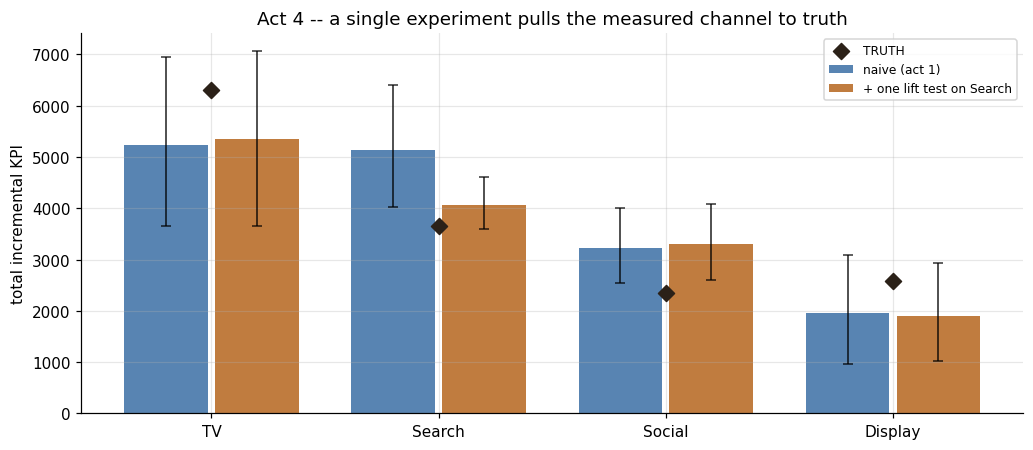

,naive err,calibrated err,naive CI,calibrated CI,lift-tested
channel,,,,,
TV,-17%,-15%,0.63,0.64,
Search,+41%,+11%,0.46,0.25,<-- HERE
Social,+38%,+40%,0.45,0.45,
Display,-24%,-27%,1.09,1.01,


In [25]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
truth_vs_estimate(ax, {"naive (act 1)": (g1a, c1a),
                       f"+ one lift test on {target}": (g4, c4)},
                  sc1.channels,
                  "Act 4 -- a single experiment pulls the measured channel to truth")
plt.tight_layout(); plt.show()

cmp4 = pd.DataFrame({
    "naive err": g1a["err"], "calibrated err": g4["err"],
    "naive CI": g1a["rel_CI_width"], "calibrated CI": g4["rel_CI_width"]})
cmp4["lift-tested"] = ["<-- HERE" if c == target else "" for c in cmp4.index]
display(cmp4)

In [26]:
# VERIFY: calibration is surgical.
assert abs(g4.loc[target, "err_frac"]) < abs(g1a.loc[target, "err_frac"]) / 2, \
    "the tested channel's bias should collapse"
assert g4.loc[target, "in 90% CI"] == "Y", "truth back inside the interval"
assert g4.loc[target, "rel_CI_width"] < g1a.loc[target, "rel_CI_width"] * 0.7, \
    "the tested channel's interval should contract sharply"
others = [c for c in chasers if c != target]
if others:
    o = others[0]
    assert abs(g4.loc[o, "err_frac"]) > 0.2, \
        "the OTHER confounded channel should remain biased (no test, no fix)"
    print(f"confirmed: {target} snaps to truth with a tighter interval; "
          f"{o} (confounded, untested) barely moves -- still "
          f"{g4.loc[o, 'err']} off.")

confirmed: Search snaps to truth with a tighter interval; Social (confounded, untested) barely moves -- still +40% off.


> **Takeaway 4.** One number bought from outside the dataset did what no
> control, prior, or diagnostic could: the tested channel snaps back inside its
> (now much tighter) interval, while the *other* demand-chasing channel — same
> mechanism, no experiment — keeps its bias almost untouched. Calibration is
> **surgical, not systemic**: it repairs the channels you measure, at the rate
> of one experiment per identification problem. Run them where the money is
> and where this notebook's failure modes live: the biggest spenders, the
> demand-chasers, and one member of every collinear group.

In [27]:
budget = pd.Series(TIMINGS, name="seconds")
display(budget.to_frame())
print(f"total sampling time: {budget.sum():.0f}s across {len(budget)} fits "
      f"({DRAWS} draws x {CHAINS} chains, numpyro).")

,seconds
act1 naive,7.3
act1 proxy-controlled,6.1
act2 collinear,7.5
act3 (a) all-25 no selection,10.1
act3 (b) horseshoe,11.1
act3 (c) oracle 3 controls,6.4
act3 (d) spike-slab,13.0
act4 calibrated,9.2


total sampling time: 71s across 8 fits (300 draws x 2 chains, numpyro).


---
# What to remember

1. **Confounding is silent.** Convergence, PPC, even the targeted RV screen —
   all quiet while a demand-chasing channel reports double its true effect.
   Exogeneity lives in the world, not the trace. The only EDA tell is
   spend-vs-demand-proxy correlation, and even a modest one is enough.
2. **"Controlled for" is a spectrum, not a checkbox.** A noisy proxy closes
   most of the back-door; the rest is a residual bias whose size the data
   cannot tell you. Proxy quality is part of the spec.
3. **Causal roles are SPEC.** Confounders get the wide un-shrunk prior;
   mediators are refused outright; precision controls may be regularized. No
   correlation screen makes these calls — the decoys correlate with everything
   and cause nothing.
4. **Selection is for the nuisance pile only.** Horseshoe/spike-slab crushed 18
   noise walks and 4 decoys, matched the oracle's media recovery, and kept the
   confounder whole — *because the confounder was exempt by role*. The same
   shrinkage that cleans junk also attenuates real-but-weak controls; never let
   it touch a back-door.
5. **Collinear channels need experiments, not priors.** Wide per-channel
   intervals around a well-identified total are the model being honest;
   tightening priors converts honesty into invention.
6. **The decision ladder: observational → controlled → calibrated.** Each rung
   buys identification the previous one cannot. The last rung is the only one
   that pays off a confounded channel in full — one experiment per channel you
   need to defend.

**Next:** [stress_04_extension_traps](stress_04_extension_traps.ipynb) — the
extended models (nested mediation, multivariate KPIs): when extra structure
genuinely helps, and when it just adds unidentifiable knobs that *feel* like
rigor. The capstone, [stress_05_the_gauntlet](stress_05_the_gauntlet.ipynb),
runs the full workflow on a world with everything at once.